# Pokémon TCG AI Battle — Card Data EDA

Competition: [pokemon-tcg-ai-battle](https://www.kaggle.com/competitions/pokemon-tcg-ai-battle)
(Simulation Track). We submit an **agent** (`agent(obs) -> list[int]`) plus a
60-card `deck.csv`; matches are scored by **Elo** on a ladder. Community wisdom:
*deck choice dominates agent quality*, so understanding the card pool is step one.

This notebook explores the ~1,250-card Standard pool shipped as
`data/EN_Card_Data.csv` (one row per move/ability). Parsing lives in
`src/cards.py`.

In [1]:
import sys
from pathlib import Path

# Make `import src...` work whether the notebook runs from repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cards import load_moves, load_cards, parse_cost, ENERGY_SYMBOLS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
moves = load_moves("EN")   # one row per move/ability
cards = load_cards("EN")   # one row per unique card
print(f"move rows: {len(moves):,}   unique cards: {len(cards):,}")
cards.head()

move rows: 2,022   unique cards: 1,267


,card_id,name,expansion,supertype,stage_or_type,rule,category,previous_stage,hp,type_code,weakness_code,retreat,n_moves,move_names,max_damage,max_cost,is_ex,is_mega,is_ace_spec
0,1,Basic {G} Energy,SVE,Energy,Basic Energy,None,None,None,NaN,G,None,NaN,0,[],NaN,0,False,False,False
1,2,Basic {R} Energy,SVE,Energy,Basic Energy,None,None,None,NaN,R,None,NaN,0,[],NaN,0,False,False,False
2,3,Basic {W} Energy,SVE,Energy,Basic Energy,None,None,None,NaN,W,None,NaN,0,[],NaN,0,False,False,False
3,4,Basic {L} Energy,SVE,Energy,Basic Energy,None,None,None,NaN,L,None,NaN,0,[],NaN,0,False,False,False
4,5,Basic {P} Energy,SVE,Energy,Basic Energy,None,None,None,NaN,P,None,NaN,0,[],NaN,0,False,False,False


## 1. Card pool composition

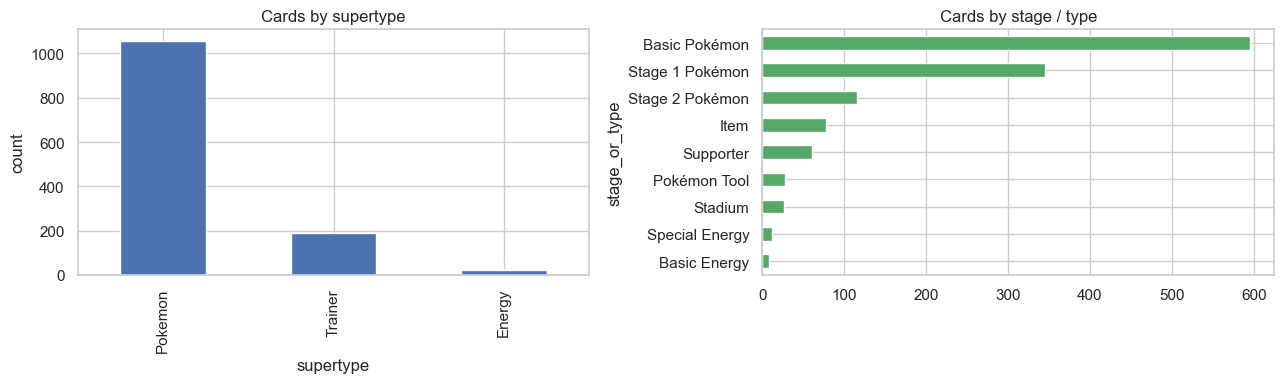

supertype
Pokemon    1056
Trainer     191
Energy       20
Name: count, dtype: int64

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cards["supertype"].value_counts().plot.bar(ax=ax[0], color="#4c72b0")
ax[0].set_title("Cards by supertype")
ax[0].set_ylabel("count")
cards["stage_or_type"].value_counts().plot.barh(ax=ax[1], color="#55a868")
ax[1].set_title("Cards by stage / type")
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

cards["supertype"].value_counts()

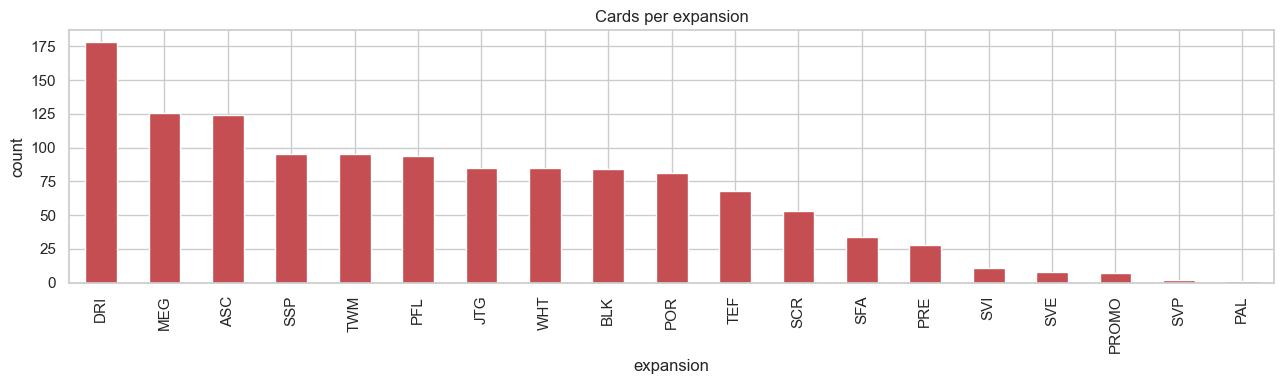

In [4]:
# Expansions present in the pool (set rotation matters for deck building).
ax = cards["expansion"].value_counts().plot.bar(figsize=(13, 4), color="#c44e52")
ax.set_title("Cards per expansion")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 2. Pokémon: HP, type, stage, retreat

These drive the "engine" of a deck: how tanky attackers are, what energy colors
you must run, and how easy Pokémon are to retreat.

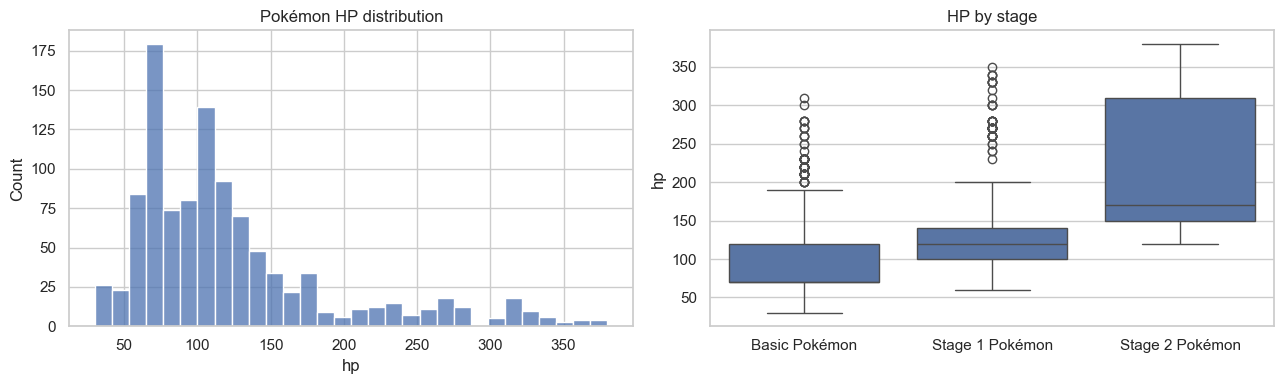

count    1056.000000
mean      122.405303
std        70.266187
min        30.000000
25%        70.000000
50%       100.000000
75%       140.000000
max       380.000000
Name: hp, dtype: float64

In [5]:
pk = cards[cards["supertype"] == "Pokemon"].copy()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=pk, x="hp", bins=30, ax=ax[0], color="#4c72b0")
ax[0].set_title("Pokémon HP distribution")

order = ["Basic Pokémon", "Stage 1 Pokémon", "Stage 2 Pokémon"]
sns.boxplot(data=pk, x="stage_or_type", y="hp", order=order, ax=ax[1])
ax[1].set_title("HP by stage")
ax[1].set_xlabel("")
plt.tight_layout()
plt.show()

pk["hp"].describe()

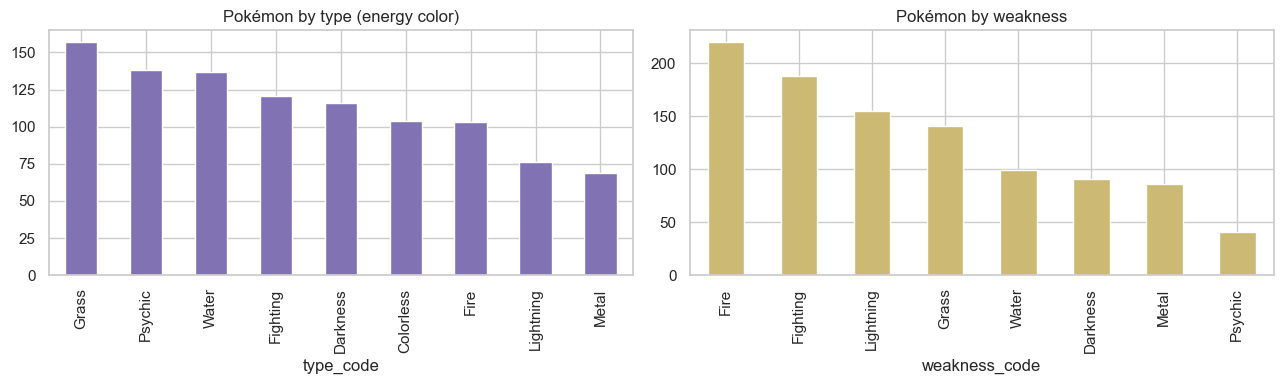

In [6]:
# Energy-color identity of the Pokémon pool + most common weaknesses.
color_name = lambda s: s.map(lambda c: ENERGY_SYMBOLS.get(c, c))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
color_name(pk["type_code"]).value_counts().plot.bar(ax=ax[0], color="#8172b3")
ax[0].set_title("Pokémon by type (energy color)")
color_name(pk["weakness_code"]).value_counts().plot.bar(ax=ax[1], color="#ccb974")
ax[1].set_title("Pokémon by weakness")
plt.tight_layout()
plt.show()

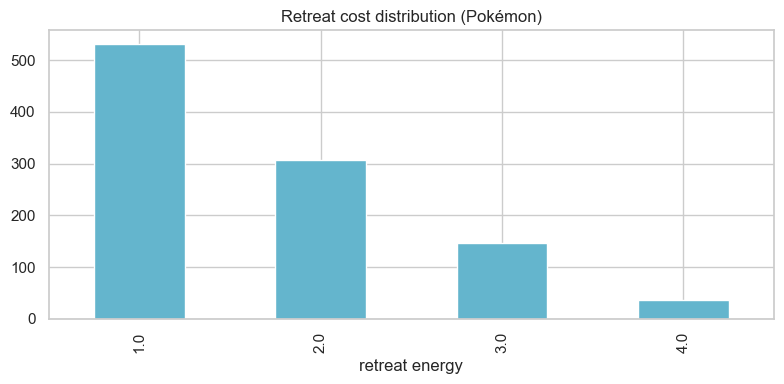

In [7]:
# Retreat cost: cheap-retreat attackers and good "pivot" Pokémon are valuable.
ax = pk["retreat"].value_counts().sort_index().plot.bar(
    figsize=(8, 4), color="#64b5cd"
)
ax.set_title("Retreat cost distribution (Pokémon)")
ax.set_xlabel("retreat energy")
plt.tight_layout()
plt.show()

### ex / Mega / ACE SPEC

`ex` Pokémon give up an **extra prize** when KO'd (Mega ex give up more), so
they trade raw power for prize risk. ACE SPEC cards are limited to **one per
deck**. These flags shape both deck slots and ladder risk.

ex: 151 | mega: 30 | ace spec: 29


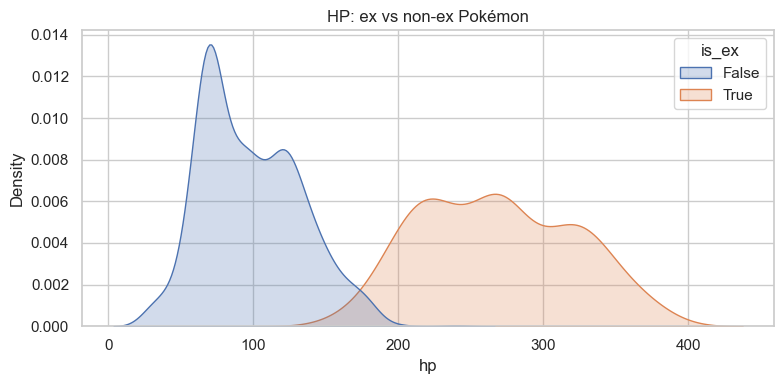

In [8]:
print("ex:", int(pk["is_ex"].sum()),
      "| mega:", int(pk["is_mega"].sum()),
      "| ace spec:", int(cards["is_ace_spec"].sum()))

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=pk, x="hp", hue="is_ex", fill=True, common_norm=False, ax=ax)
ax.set_title("HP: ex vs non-ex Pokémon")
plt.tight_layout()
plt.show()

## 3. Attacks: cost vs damage

Damage-per-energy is the crude "tempo" measure. Watch for cheap high-damage
attacks (likely have drawbacks in the effect text) and for which energy colors
attacks demand.

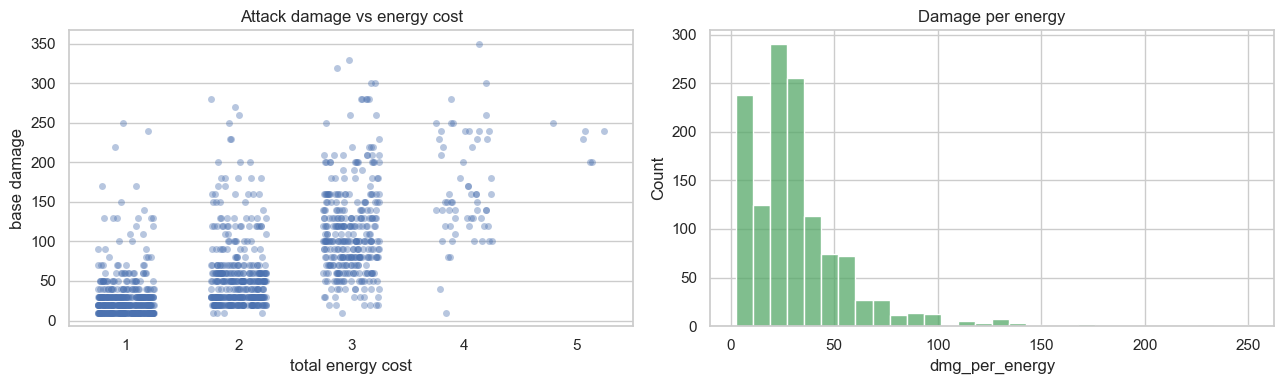

In [9]:
atk = moves[moves["is_attack"]].copy()
atk = atk[atk["damage_value"].notna() & (atk["cost_total"] > 0)]
atk["dmg_per_energy"] = atk["damage_value"] / atk["cost_total"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.stripplot(data=atk, x="cost_total", y="damage_value", ax=ax[0],
              alpha=0.4, color="#4c72b0", jitter=0.25)
ax[0].set_title("Attack damage vs energy cost")
ax[0].set_xlabel("total energy cost")
ax[0].set_ylabel("base damage")
sns.histplot(data=atk, x="dmg_per_energy", bins=30, ax=ax[1], color="#55a868")
ax[1].set_title("Damage per energy")
plt.tight_layout()
plt.show()

In [10]:
# Most energy-efficient attacks (raw base damage / cost). Effects often explain
# why these are "too good" — read the effect column before trusting the number.
cols = ["name", "move_name", "cost", "damage", "cost_total",
        "damage_value", "dmg_per_energy", "effect"]
atk.nlargest(12, "dmg_per_energy")[cols].reset_index(drop=True)

,name,move_name,cost,damage,cost_total,damage_value,dmg_per_energy,effect
0,Palafin ex,Giga Impact,{W},250,1,250.0,250.0,"During your next turn, this Pokémon can’t use ..."
1,Tinkaton,Windup Swing,{M},-240,1,240.0,240.0,This attack does 60 less damage for each Energ...
2,Ceruledge,Infernal Slash,{R},220,1,220.0,220.0,Discard 4 Basic {R} Energy cards from your han...
3,Greninja ex,Shinobi Blade,{W},170,1,170.0,170.0,You may search your deck for a card and put it...
4,Decidueye,Power Shot,{G},170,1,170.0,170.0,Discard a Basic {G} Energy card from your hand...
5,Medicham,Seventh Kick,{F},150,1,150.0,150.0,If you don’t have exactly 7 cards in your hand...
6,Slaking ex,Great Swing,●●,280,2,280.0,140.0,Discard an Energy from this Pokémon.
7,Diggersby,Earthquake,●,140,1,140.0,140.0,This attack also does 30 damage to each of you...
8,Mega Lucario ex,Mega Brave,{F}{F},270,2,270.0,135.0,"During your next turn, this Pokémon can’t use ..."
9,Palafin,Vanguard Punch,{W},130,1,130.0,130.0,This Pokémon also does 10 damage to itself for...


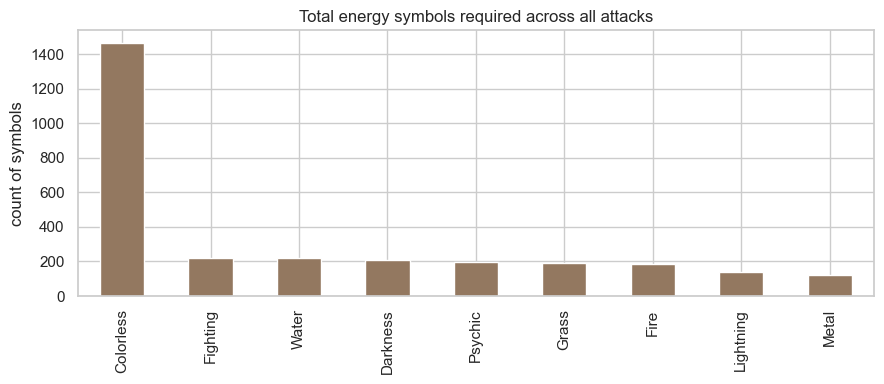

Colorless    1464
Fighting      218
Water         218
Darkness      207
Psychic       197
Grass         193
Fire          187
Lightning     137
Metal         123
dtype: int64

In [11]:
# Aggregate energy-color demand across every attack cost in the pool.
# Tells you which colors the format is built around.
demand = {}
for cost in moves["cost"].dropna():
    for code, n in parse_cost(cost).items():
        demand[code] = demand.get(code, 0) + n
demand = (
    pd.Series(demand)
    .rename(index=lambda c: ENERGY_SYMBOLS.get(c, c))
    .sort_values(ascending=False)
)
ax = demand.plot.bar(figsize=(9, 4), color="#937860")
ax.set_title("Total energy symbols required across all attacks")
ax.set_ylabel("count of symbols")
plt.tight_layout()
plt.show()
demand

## 4. Trainers & Energy

In [12]:
trainers = cards[cards["supertype"] == "Trainer"]
print(trainers["stage_or_type"].value_counts().to_string())
print()
print("Energy cards:")
print(cards[cards["supertype"] == "Energy"][["card_id", "name", "stage_or_type"]]
      .to_string(index=False))

stage_or_type
Item            77
Supporter       61
Pokémon Tool    27
Stadium         26

Energy cards:
 card_id                    name  stage_or_type
       1        Basic {G} Energy   Basic Energy
       2        Basic {R} Energy   Basic Energy
       3        Basic {W} Energy   Basic Energy
       4        Basic {L} Energy   Basic Energy
       5        Basic {P} Energy   Basic Energy
       6        Basic {F} Energy   Basic Energy
       7        Basic {D} Energy   Basic Energy
       8        Basic {M} Energy   Basic Energy
       9        Boomerang Energy Special Energy
      10        Neo Upper Energy Special Energy
      11             Mist Energy Special Energy
      12           Legacy Energy Special Energy
      13        Enriching Energy Special Energy
      14            Spiky Energy Special Energy
      15    Team Rocket's Energy Special Energy
      16            Prism Energy Special Energy
      17         Ignition Energy Special Energy
      18       Grow Grass Energ

In [13]:
# Supporters are the deck's draw/disruption engine — skim the pool by name.
sup = trainers[trainers["stage_or_type"] == "Supporter"]
sorted(sup["name"].unique().tolist())

["Acerola's Mischief",
 'Amarys',
 'Anthea & Concordia',
 'Bianca’s Devotion',
 "Billy & O'Nare",
 'Black Belt’s Training',
 'Boss’s Orders',
 'Briar',
 'Brock’s Scouting',
 'Canari',
 'Carmine',
 'Cassiopeia',
 'Cheren',
 'Ciphermaniac’s Codebreaking',
 'Colress’s Tenacity',
 'Cook',
 'Crispin',
 'Cyrano',
 'Dawn',
 'Drayton',
 "Emcee's Hype",
 'Eri',
 "Ethan's Adventure",
 'Explorer’s Guidance',
 'Fennel',
 'Firebreather',
 "Grimsley's Move",
 'Harlequin',
 'Hassel',
 'Hilda',
 'Iris’s Fighting Spirit',
 'Jacinthe',
 'Janine’s Secret Art',
 'Judge',
 'Kieran',
 'Kofu',
 'Lacey',
 'Lana’s Aid',
 'Larry’s Skill',
 "Lillie's Determination",
 'Lisia’s Appeal',
 "Lt. Surge's Bargain",
 'Lucian',
 'Morty’s Conviction',
 "N's Plan",
 'Naveen',
 'Perrin',
 "Rosa's Encouragement",
 'Ruffian',
 'Salvatore',
 'Surfer',
 'Tarragon',
 "Team Rocket's Archer",
 "Team Rocket's Ariana",
 "Team Rocket's Giovanni",
 "Team Rocket's Petrel",
 "Team Rocket's Proton",
 'Urbain',
 'Waitress',
 "Wally's Comp

## 5. Deck-building lens — decode the sample deck

The sample submission ships a 60-card `deck.csv` (one card ID per line). Decoding
it shows a real, legal deck and its energy identity — a useful baseline before we
build our own.

In [14]:
deck_path = ROOT / "data" / "sample_submission" / "deck.csv"
deck_ids = [int(x) for x in deck_path.read_text().split() if x.strip()]
print(f"deck size: {len(deck_ids)} (must be 60)")

id_to = cards.set_index("card_id")
deck = (
    pd.Series(deck_ids, name="card_id")
    .map(id_to["name"])
    .value_counts()
    .rename_axis("name")
    .reset_index(name="count")
)
deck = deck.merge(
    cards[["name", "supertype", "stage_or_type", "type_code"]].drop_duplicates("name"),
    on="name", how="left",
)
deck.sort_values(["supertype", "count"], ascending=[True, False]).reset_index(drop=True)

deck size: 60 (must be 60)


,name,count,supertype,stage_or_type,type_code
0,Basic {W} Energy,35,Energy,Basic Energy,W
1,Snover,4,Pokemon,Basic Pokémon,W
2,Mega Abomasnow ex,4,Pokemon,Stage 1 Pokémon,W
3,Kyogre,2,Pokemon,Basic Pokémon,W
4,Mega Signal,4,Trainer,Item,None
5,Lillie's Determination,4,Trainer,Supporter,None
6,Waitress,4,Trainer,Supporter,None
7,Cyrano,2,Trainer,Supporter,None
8,Maximum Belt,1,Trainer,Pokémon Tool,None


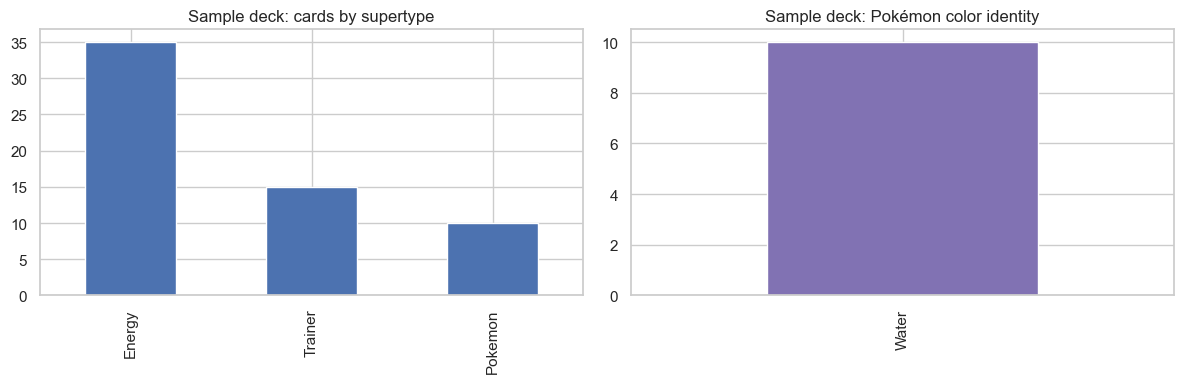

In [15]:
# Composition of the sample deck: Pokémon vs Trainer vs Energy, and color identity.
by_super = (
    pd.Series(deck_ids).map(id_to["supertype"]).value_counts()
)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_super.plot.bar(ax=ax[0], color="#4c72b0")
ax[0].set_title("Sample deck: cards by supertype")

pk_ids = [i for i in deck_ids if id_to.loc[i, "supertype"] == "Pokemon"]
pd.Series(pk_ids).map(id_to["type_code"]).map(
    lambda c: ENERGY_SYMBOLS.get(c, c)
).value_counts().plot.bar(ax=ax[1], color="#8172b3")
ax[1].set_title("Sample deck: Pokémon color identity")
plt.tight_layout()
plt.show()

## Takeaways & next steps

- The pool is **~1,250 Standard cards**: mostly Pokémon, with a focused set of
  Trainers (draw/disruption) and a handful of Energy cards.
- Deck building is constrained by **energy color identity**, **stage lines**
  (Basic → Stage 1 → Stage 2), and **prize risk** (ex/Mega give up extra prizes).
- High damage-per-energy attacks almost always carry a drawback in the effect
  text — read it before trusting the number.

**Next:**
1. Pick / refine a deck archetype (the single biggest lever on ladder Elo).
2. Stand up the **simulator** (Linux x86-64 only — see README) to run battles and
   the `search_*` lookahead API.
3. Build a first heuristic `agent()` that beats the random baseline, then iterate
   against the live ladder (5 submissions/day).